# Predicción del Peso Final de Pollos de Engorde

**Variable objetivo:** `Peso_Final_g` (regresión).
**Autor:** Ethan Taipe · **Stack:** Python (pandas, scikit-learn, statsmodels, XGBoost, LightGBM).

---

## Resumen

Este cuaderno desarrolla, documenta y justifica una solución completa de Machine Learning para predecir el
peso de pollos de engorde, siguiendo las siete "reglas del juego" del reto y llevándolo más allá de la
predicción: traducimos los hallazgos en **decisiones capitalizables** (qué línea genética conviene engordar,
cuánto vale en dinero esa decisión, y qué variables realmente importan).

**Hallazgos clave:**

1. **El peso está gobernado por la edad y el consumo de alimento.** Juntas explican casi toda la varianza
   (R² ≈ 0.98 solo con la edad). El resto de variables aportan señal marginal.
2. **Las variables ambientales (temperatura, humedad) y la mortalidad son, en este dataset, ruido**: su
   correlación e información mutua con el objetivo son ≈ 0. Esto es un hallazgo de *calidad de dato*, no una
   verdad biológica (la literatura sí documenta efectos del ambiente; ver §1 y §7).
3. **Ranking de líneas genéticas (controlando edad y sexo):** **Cobb 500 > Ross 308 > Arbor Acres**, con
   efectos estadísticamente significativos. Coincide con la evidencia científica en clima tropical.
4. **El sexo pesa más que la línea:** los machos rinden ~+126 g/ave frente a las hembras.
5. **Riesgo de fuga de información (data leakage) controlado:** la ganancia de peso, la GDP y el FCR se
   derivan del objetivo, por lo que se usan **solo como descriptores de negocio**, nunca como predictores.

> **Cómo leer este cuaderno.** Cada sección está rotulada con la regla del reto que satisface. El código es
> reproducible (semillas fijas) y los artefactos (figuras, tablas, resumen) se guardan en `../outputs/`.


## 0. Configuración del entorno

Fijamos semillas para reproducibilidad y definimos rutas de salida. Todo el cuaderno asume la estructura del
repositorio descrita en el `README.md` (`data/`, `notebooks/`, `outputs/`).

In [1]:
%matplotlib inline
import numpy as np, pandas as pd, json, warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {"Arbor Acres": "#4C72B0", "Cobb 500": "#DD8452", "Ross 308": "#55A868"}
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
                     "axes.titleweight": "bold", "font.size": 10})

FIG = Path("../outputs/figures"); FIG.mkdir(parents=True, exist_ok=True)
TAB = Path("../outputs/tablas");  TAB.mkdir(parents=True, exist_ok=True)
print("Entorno listo. Figuras ->", FIG, "| Tablas ->", TAB)

Entorno listo. Figuras -> ..\outputs\figures | Tablas -> ..\outputs\tablas


## 1. Carga de datos

Leemos la hoja `Datos_Pollos` del libro de Excel. Trabajamos siempre sobre una copia para no mutar la fuente.

In [ ]:
DATA = Path("../data/Data_caso_practico.xlsx") #DATASET OMITIDO EN EL REPOSITORIO POR POLITICAS DE PRIVACIDAD RELACIONADAS AL PROCESO DE SELECCION/ APUNTAR HACIA EL DOCUMENTO EN SU ENTORNO
#DATA = Path("C:/Users/ASUS GAMING/Downloads/Data caso práctico.xlsx") EJEMPLO DE USO
df = pd.read_excel(DATA, sheet_name="Datos_Pollos")
print(f"Registros: {df.shape[0]:,} | Variables: {df.shape[1]}")
df.head(8)

Registros: 1,000 | Variables: 11


,ID_Lote,Edad_Dias,Consumo_Alimento_g_dia,Temperatura_C,Humedad_%,Densidad_Aves_m2,Mortalidad_%,Sexo,Linea_Genetica,Peso_Inicial_g,Peso_Final_g
0,1,35,177.4,23.1,52.5,8.4,1.00,Macho,Arbor Acres,47.1,2833.5
1,2,1,46.1,32.5,77.4,9.8,3.86,Hembra,Arbor Acres,45.1,312.6
2,3,41,181.5,23.8,63.8,17.6,1.08,Macho,Ross 308,42.2,3298.3
3,4,16,96.6,27.3,72.6,12.1,2.60,Macho,Arbor Acres,43.5,1539.7
4,5,3,47.1,24.6,77.1,15.7,0.97,Hembra,Cobb 500,41.9,517.5
5,6,29,148.7,28.4,54.3,12.4,2.93,Hembra,Arbor Acres,39.3,2400.2
6,7,14,75.4,24.4,84.8,17.1,5.53,Hembra,Arbor Acres,40.7,1120.2
7,8,22,112.4,33.5,76.6,12.6,0.99,Macho,Cobb 500,39.7,1862.0


## Regla 1 — Conoce a tus pollos
### 1.1 Tipos de variables y rol en el problema

Antes de tocar nada, documentamos qué representa cada variable y su rol previsto. Ademas de programar un modelo lo que buscamos es **entender el negocio**: las tres líneas genéticas (`Arbor Acres`, `Cobb 500`,
`Ross 308`) son las estirpes comerciales de pollo de engorde más usadas del mundo, y el ciclo productivo
típico va de 1 a ~42 días, justo el rango de `Edad_Dias`.

In [3]:
diccionario = pd.DataFrame([
 ("ID_Lote","Identificador único del lote","Numérica (ID)","No predictora"),
 ("Edad_Dias","Edad del lote al registro (días)","Numérica discreta","Predictora"),
 ("Consumo_Alimento_g_dia","Consumo de alimento por ave por día (g)","Numérica continua","Predictora"),
 ("Temperatura_C","Temperatura del galpón (°C)","Numérica continua","Predictora (ambiental)"),
 ("Humedad_%","Humedad relativa (%)","Numérica continua","Predictora (ambiental)"),
 ("Densidad_Aves_m2","Densidad de aves por m²","Numérica continua","Predictora (manejo)"),
 ("Mortalidad_%","Mortalidad del lote (%)","Numérica continua","Predictora (sanidad)"),
 ("Sexo","Sexo del lote (Macho/Hembra)","Categórica nominal","Predictora"),
 ("Linea_Genetica","Línea genética / estirpe","Categórica nominal","Predictora"),
 ("Peso_Inicial_g","Peso del pollito BB al inicio (g)","Numérica continua","Predictora"),
 ("Peso_Final_g","Peso del ave al registro (g)","Numérica continua","VARIABLE OBJETIVO"),
], columns=["Variable","Descripción","Tipo","Rol"])
diccionario

,Variable,Descripción,Tipo,Rol
0,ID_Lote,Identificador único del lote,Numérica (ID),No predictora
1,Edad_Dias,Edad del lote al registro (días),Numérica discreta,Predictora
2,Consumo_Alimento_g_dia,Consumo de alimento por ave por día (g),Numérica continua,Predictora
3,Temperatura_C,Temperatura del galpón (°C),Numérica continua,Predictora (ambiental)
4,Humedad_%,Humedad relativa (%),Numérica continua,Predictora (ambiental)
5,Densidad_Aves_m2,Densidad de aves por m²,Numérica continua,Predictora (manejo)
6,Mortalidad_%,Mortalidad del lote (%),Numérica continua,Predictora (sanidad)
7,Sexo,Sexo del lote (Macho/Hembra),Categórica nominal,Predictora
8,Linea_Genetica,Línea genética / estirpe,Categórica nominal,Predictora
9,Peso_Inicial_g,Peso del pollito BB al inicio (g),Numérica continua,Predictora


### 1.2 Calidad de la información

Revisamos tipos reales (`dtype`), valores faltantes, duplicados y unicidad. Buscamos explorar la calidad del dataset previo a empezar a modelar.

In [4]:
resumen = pd.DataFrame({
    "Tipo (dtype)": df.dtypes.astype(str),
    "N_nulos": df.isnull().sum(),
    "%_nulos": (df.isnull().mean()*100).round(2),
    "N_unicos": df.nunique(),
    "Min": df.select_dtypes(include=np.number).min(),
    "Max": df.select_dtypes(include=np.number).max(),
})
print("Duplicados (filas completas):", int(df.duplicated().sum()))
print("Duplicados en ID_Lote     :", int(df['ID_Lote'].duplicated().sum()))
resumen

Duplicados (filas completas): 0
Duplicados en ID_Lote     : 0


,Tipo (dtype),N_nulos,%_nulos,N_unicos,Min,Max
Consumo_Alimento_g_dia,float64,0,0.0,771,20.0,231.10
Densidad_Aves_m2,float64,0,0.0,101,8.0,18.00
Edad_Dias,int64,0,0.0,42,1.0,42.00
Humedad_%,float64,0,0.0,376,45.0,85.00
ID_Lote,int64,0,0.0,1000,1.0,1000.00
Linea_Genetica,object,0,0.0,3,NaN,NaN
Mortalidad_%,float64,0,0.0,406,0.0,6.48
Peso_Final_g,float64,0,0.0,975,135.0,3596.30
Peso_Inicial_g,float64,0,0.0,101,38.0,48.00
Sexo,object,0,0.0,2,NaN,NaN


### 1.3 Estadística descriptiva

Los percentiles, mínimos y máximos confirman que los rangos son plausibles para avicultura
(p. ej. `Edad_Dias` 1–42, `Peso_Final_g` 135–3596 g). Las clases categóricas están **balanceadas**, lo que
facilita comparaciones justas entre grupos.

In [5]:
display(df.describe().T.round(2))
for c in ["Sexo", "Linea_Genetica"]:
    print(f"\n{c}:"); print(df[c].value_counts().to_string())

,count,mean,std,min,25%,50%,75%,max
ID_Lote,1000.0,500.50,288.82,1.0,250.75,500.50,750.25,1000.00
Edad_Dias,1000.0,21.44,12.16,1.0,11.00,22.00,32.00,42.00
Consumo_Alimento_g_dia,1000.0,122.04,48.82,20.0,79.58,121.00,163.35,231.10
Temperatura_C,1000.0,26.95,4.05,20.0,23.50,26.80,30.52,34.00
Humedad_%,1000.0,64.74,11.34,45.0,55.38,64.70,74.20,85.00
Densidad_Aves_m2,1000.0,12.87,2.83,8.0,10.50,12.90,15.30,18.00
Mortalidad_%,1000.0,2.55,1.22,0.0,1.74,2.49,3.38,6.48
Peso_Inicial_g,1000.0,43.07,2.87,38.0,40.70,43.00,45.42,48.00
Peso_Final_g,1000.0,1847.63,909.39,135.0,1077.70,1844.85,2599.38,3596.30



Sexo:
Sexo
Hembra    511
Macho     489

Linea_Genetica:
Linea_Genetica
Arbor Acres    339
Ross 308       332
Cobb 500       329


### 1.4 Detección de inconsistencias

Realizamos tres chequeos de coherencia:

- **Coherencia física peso:** el peso del ave nunca debería ser menor o igual al peso inicial.
- **Ganancia diaria implícita:** ganancia / edad. En broilers la ganancia diaria pico ronda 80–100 g/día.
- **Centinelas:** valores como −999 / 999 que suelen codificar faltantes.

> **Hallazgo (artefacto del dato).** A día 1 el peso medio es ~370 g, cuando un pollito BB pesa ~40–45 g
> (de hecho `Peso_Inicial_g` ∈ [38, 48], correcto). Esto implica que `Peso_Final_g` se generó como una
> **función lineal de la edad con intercepto no físico (~260 g)**, en lugar de una curva sigmoidea real.
> Es una característica de *dato sintético*: la documentamos como **limitación**, pero **no eliminamos**
> esas filas, porque son consistentes con el patrón del propio dataset (no son outliers).

In [6]:
# Coherencia física
print("Filas con Peso_Final <= Peso_Inicial:", int((df['Peso_Final_g'] <= df['Peso_Inicial_g']).sum()))

# Ganancia diaria implícita (solo diagnóstico, NO es feature)
gdp = (df['Peso_Final_g'] - df['Peso_Inicial_g']) / df['Edad_Dias']
print(f"Ganancia diaria implícita (g/día) -> min {gdp.min():.1f} | mediana {gdp.median():.1f} | max {gdp.max():.1f}")
print(f"Peso medio a 1 día: {df.loc[df['Edad_Dias']==1,'Peso_Final_g'].mean():.1f} g "
      f"(un pollito BB real pesa ~40-45 g)")

# Búsqueda de centinelas
num = df.select_dtypes(include=np.number)
for s in [-999, -1, 999, 9999, -9999]:
    hits = (num == s).sum(); hits = hits[hits > 0]
    if len(hits): print(f"Centinela {s}: {dict(hits)}  (¿código de faltante?)")
print("\nNota: '999' aparece solo como ID_Lote (es un identificador secuencial, no un centinela).")

Filas con Peso_Final <= Peso_Inicial: 0
Ganancia diaria implícita (g/día) -> min 61.2 | mediana 84.2 | max 585.6
Peso medio a 1 día: 373.6 g (un pollito BB real pesa ~40-45 g)
Centinela 999: {'ID_Lote': np.int64(1)}  (¿código de faltante?)

Nota: '999' aparece solo como ID_Lote (es un identificador secuencial, no un centinela).


## Regla 2 — Prepara el terreno
### 2.1 Valores faltantes

El dataset no presenta faltantes explícitos ni encubiertos. Aun así, **dejamos preparada la imputación en el
pipeline** (mediana para numéricas, moda para categóricas) como buena práctica de robustez: si mañana llega
un lote con campos vacíos, el modelo no se rompe en producción.

### 2.2 Detección de valores atípicos (outliers)

Combinamos dos criterios: **IQR (1.5×)** por variable y **residuos de la curva de crecimiento** (un peso
"raro" solo lo es *para su edad*). Un punto puede no ser outlier global pero sí desviarse mucho de lo
esperable dada su edad — por eso el segundo criterio es superior aquí.

In [8]:
#!pip install statsmodels --quiet
import statsmodels.formula.api as smf
d = df.rename(columns={'Humedad_%':'Humedad_pct', 'Mortalidad_%':'Mortalidad_pct'})

# (a) IQR por variable
rows = []
for c in df.select_dtypes(include=np.number).columns:
    if c == 'ID_Lote': continue
    q1, q3 = df[c].quantile([.25, .75]); iqr = q3 - q1
    n = int(((df[c] < q1 - 1.5*iqr) | (df[c] > q3 + 1.5*iqr)).sum())
    rows.append((c, n))
iqr_tbl = pd.DataFrame(rows, columns=["Variable", "N_outliers_IQR"])

# (b) Residuos respecto a la curva de crecimiento Peso ~ Edad
res = smf.ols("Peso_Final_g ~ Edad_Dias", data=d).fit().resid
z = (res - res.mean()) / res.std()
print(f"Outliers vs curva de crecimiento  |z|>3: {(z.abs()>3).sum()}  |  |z|>4: {(z.abs()>4).sum()}")
print("\nOutliers por IQR:")
print(iqr_tbl.to_string(index=False))

Outliers vs curva de crecimiento  |z|>3: 2  |  |z|>4: 0

Outliers por IQR:
              Variable  N_outliers_IQR
             Edad_Dias               0
Consumo_Alimento_g_dia               0
         Temperatura_C               0
             Humedad_%               0
      Densidad_Aves_m2               0
          Mortalidad_%               6
        Peso_Inicial_g               0
          Peso_Final_g               0


**Decisión justificada:** prácticamente no hay outliers severos (0 puntos con |z|>4 respecto a la curva;
los pocos de `Mortalidad_%` por IQR son valores altos pero plausibles, 5–6.5%). **No eliminamos ni
winsorizamos**: hacerlo destruiría información legítima y sesgaría el modelo. Si en producción aparecieran
extremos, aplicaríamos *capping* por percentil 1/99, pero aquí no es necesario.

### 2.3 Transformación de variables e ingeniería de características (feature engineering)

Creamos características **solo si tienen una justificación de dominio** y **sin fuga de información**.

| Característica | Construcción | Justificación |
|---|---|---|
| `Edad_Dias_sq` | Edad² | Permite a los modelos lineales capturar la **desaceleración** del crecimiento (curva biológica sigmoidea). |
| `THI` | Índice Temperatura-Humedad (Thom, 1959) | Combina calor y humedad en un único índice de **estrés térmico**, métrica estándar en producción animal. |
| `Sexo_macho` | 1 si Macho | Codificación binaria del dimorfismo sexual. |

> **Control de fuga (data leakage).** `ganancia = Peso_Final − Peso_Inicial`, la `GDP` y el `FCR`
> **se calculan a partir del objetivo**. Usarlas como predictores inflaría artificialmente el desempeño y
> sería inválido en producción (no conocemos el peso final por adelantado). Las calculamos en un objeto
> separado `desc` y las reservamos **exclusivamente para el análisis de negocio** (§7).

In [9]:
data = df.rename(columns={'Humedad_%':'Humedad_pct', 'Mortalidad_%':'Mortalidad_pct'}).copy()

# --- Features SEGURAS (sin fuga) ---
data['Edad_Dias_sq'] = data['Edad_Dias']**2
T, RH = data['Temperatura_C'], data['Humedad_pct']
data['THI'] = (1.8*T + 32) - (0.55 - 0.0055*RH) * (1.8*T - 26)   # Thom (1959)
data['Sexo_macho'] = (data['Sexo'] == 'Macho').astype(int)

SAFE_NUM = ['Edad_Dias','Consumo_Alimento_g_dia','Temperatura_C','Humedad_pct',
            'Densidad_Aves_m2','Mortalidad_pct','Peso_Inicial_g','Edad_Dias_sq','THI']
SAFE_CAT = ['Sexo','Linea_Genetica']

# --- Métricas DESCRIPTIVAS (CON fuga -> NUNCA como predictores) ---
desc = pd.DataFrame(index=data.index)
desc['ganancia_g'] = data['Peso_Final_g'] - data['Peso_Inicial_g']
desc['gdp_g_dia'] = desc['ganancia_g'] / data['Edad_Dias']
desc['consumo_total_aprox_g'] = data['Consumo_Alimento_g_dia'] * data['Edad_Dias']
desc['FCR_aprox'] = desc['consumo_total_aprox_g'] / desc['ganancia_g']

print("Features de modelado SEGURAS:")
print("  Numéricas :", SAFE_NUM)
print("  Categóricas:", SAFE_CAT)
print("\nMétricas DESCRIPTIVAS (excluidas del modelo por fuga):", list(desc.columns))
desc.describe().T.round(3)

Features de modelado SEGURAS:
  Numéricas : ['Edad_Dias', 'Consumo_Alimento_g_dia', 'Temperatura_C', 'Humedad_pct', 'Densidad_Aves_m2', 'Mortalidad_pct', 'Peso_Inicial_g', 'Edad_Dias_sq', 'THI']
  Categóricas: ['Sexo', 'Linea_Genetica']

Métricas DESCRIPTIVAS (excluidas del modelo por fuga): ['ganancia_g', 'gdp_g_dia', 'consumo_total_aprox_g', 'FCR_aprox']


,count,mean,std,min,25%,50%,75%,max
ganancia_g,1000.0,1804.561,909.322,92.800,1035.775,1801.200,2555.675,3548.700
gdp_g_dia,1000.0,96.650,45.681,61.167,79.611,84.224,93.656,585.600
consumo_total_aprox_g,1000.0,3182.440,2574.971,33.600,892.775,2543.950,5181.825,9475.100
FCR_aprox,1000.0,1.430,0.689,0.067,0.853,1.447,2.028,2.883


## Regla 3 — Deja que los datos hablen
### 3.1 La curva de crecimiento

Visualizamos el peso frente a la edad. El ajuste lineal capta el 98% de la varianza y el término cuadrático
es despreciable: confirma el carácter lineal (sintético) del dato y anticipa que los modelos lineales serán
muy competitivos.

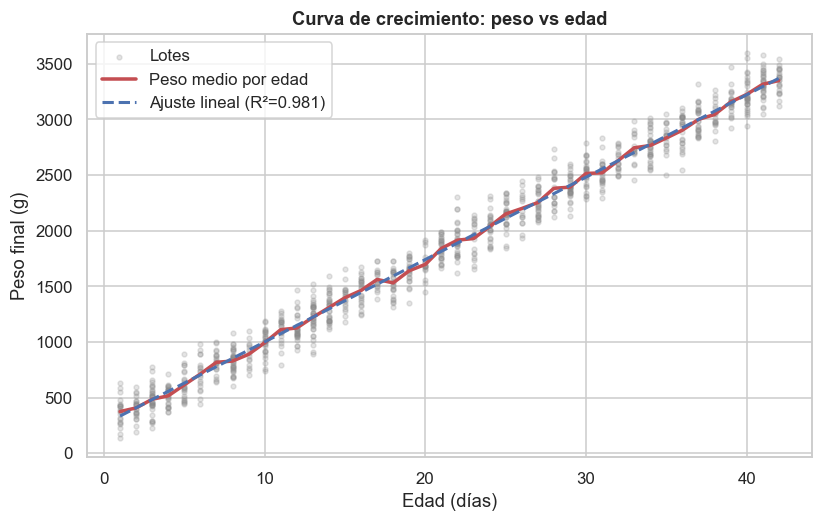

Pendiente ≈ 74.1 g/día | Intercepto ≈ 259.7 g (no físico)


In [10]:
from sklearn.metrics import r2_score
g = data.groupby('Edad_Dias')['Peso_Final_g'].mean()
b1, b0 = np.polyfit(data['Edad_Dias'], data['Peso_Final_g'], 1)
r2lin = r2_score(data['Peso_Final_g'], b1*data['Edad_Dias'] + b0)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.scatter(data['Edad_Dias'], data['Peso_Final_g'], s=10, alpha=.22, color="#888", label="Lotes")
ax.plot(g.index, g.values, color="#C44E52", lw=2.3, label="Peso medio por edad")
xs = np.linspace(1, 42, 100)
ax.plot(xs, b1*xs + b0, '--', color="#4C72B0", lw=2, label=f"Ajuste lineal (R²={r2lin:.3f})")
ax.set_xlabel("Edad (días)"); ax.set_ylabel("Peso final (g)")
ax.set_title("Curva de crecimiento: peso vs edad")
ax.legend(); plt.savefig(FIG/"01_curva_crecimiento.png"); plt.show()
print(f"Pendiente ≈ {b1:.1f} g/día | Intercepto ≈ {b0:.1f} g (no físico)")

### 3.2 Matriz de correlación

`Edad_Dias` (0.99) y `Consumo_Alimento_g_dia` (0.96) dominan la correlación con el objetivo y están **muy
correlacionadas entre sí (0.95)** — señal de multicolinealidad que abordaremos en el modelado. El ambiente y
la mortalidad rondan correlación nula.

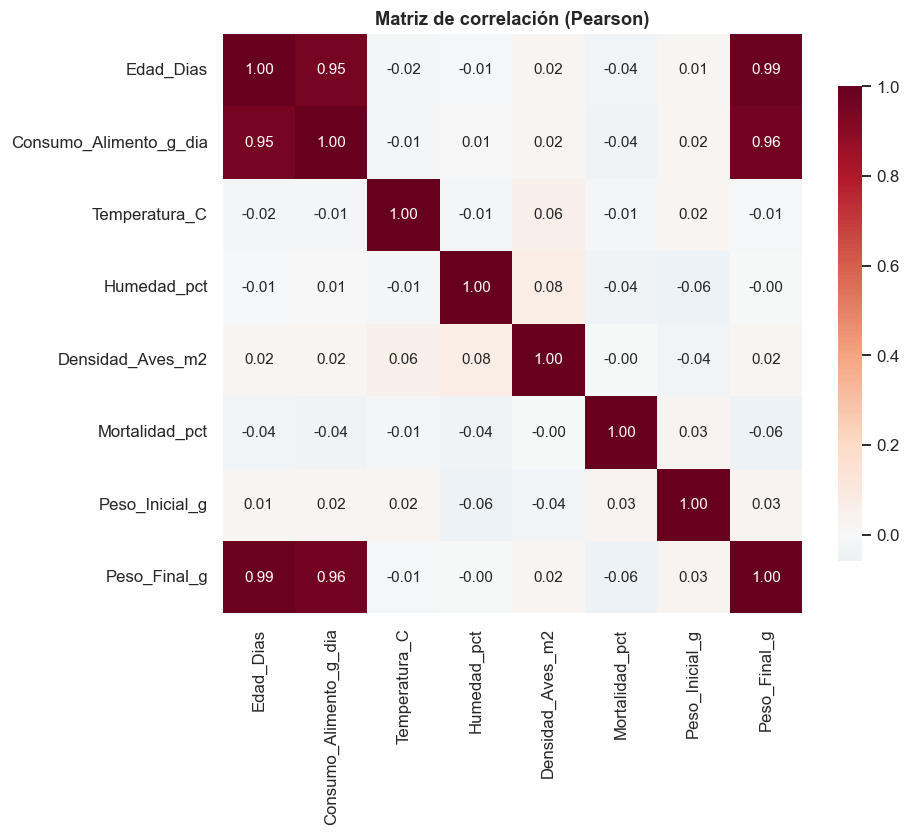

Correlación con Peso_Final_g:
Edad_Dias                 0.990
Consumo_Alimento_g_dia    0.965
Peso_Inicial_g            0.026
Densidad_Aves_m2          0.019
Humedad_pct              -0.005
Temperatura_C            -0.006
Mortalidad_pct           -0.057


In [11]:
num_corr = ['Edad_Dias','Consumo_Alimento_g_dia','Temperatura_C','Humedad_pct',
            'Densidad_Aves_m2','Mortalidad_pct','Peso_Inicial_g','Peso_Final_g']
corr = data[num_corr].corr()
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True,
            cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Matriz de correlación (Pearson)")
plt.savefig(FIG/"02_correlacion.png"); plt.show()
print("Correlación con Peso_Final_g:")
print(corr['Peso_Final_g'].drop('Peso_Final_g').sort_values(ascending=False).round(3).to_string())

### 3.3 Distribuciones del objetivo por grupos

El objetivo es ancho (mezcla de muchas edades). Por línea y por sexo aparecen diferencias que cuantificaremos
correctamente en §7 **controlando por edad** (las medias crudas pueden estar confundidas por la composición
de edades de cada grupo).

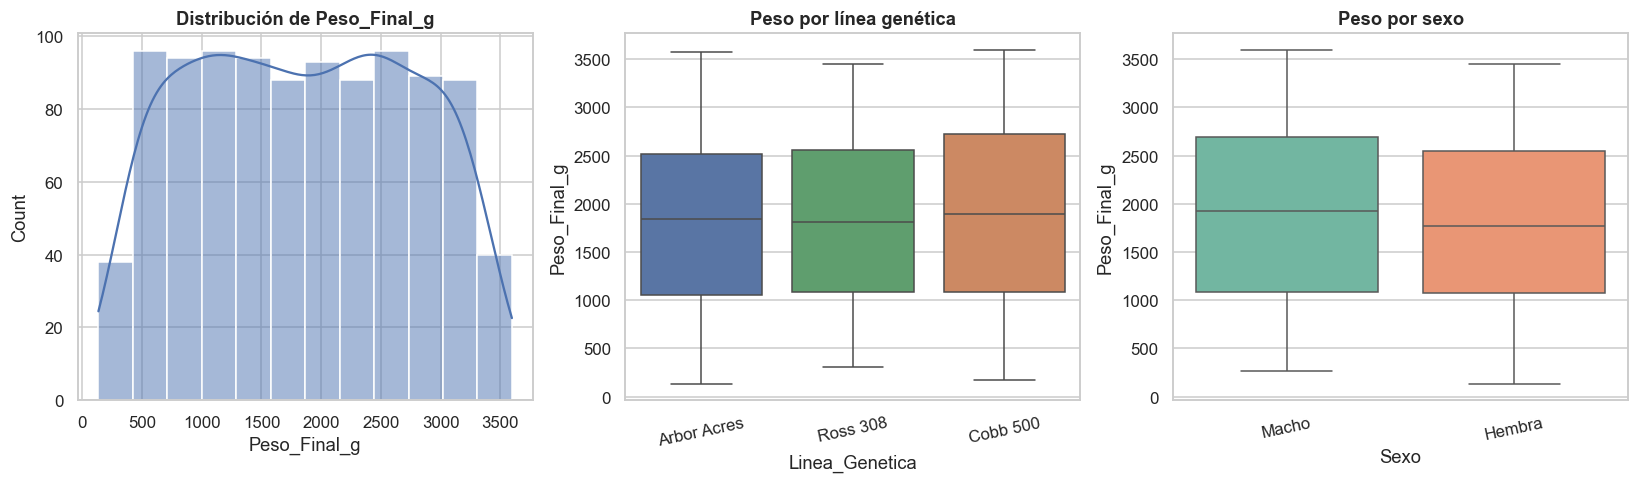

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.histplot(data['Peso_Final_g'], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribución de Peso_Final_g")
sns.boxplot(data=data, x='Linea_Genetica', y='Peso_Final_g', hue='Linea_Genetica',
            palette=PALETTE, legend=False, ax=axes[1]); axes[1].set_title("Peso por línea genética")
sns.boxplot(data=data, x='Sexo', y='Peso_Final_g', hue='Sexo',
            palette="Set2", legend=False, ax=axes[2]); axes[2].set_title("Peso por sexo")
for a in axes[1:]: a.tick_params(axis='x', rotation=12)
plt.tight_layout(); plt.savefig(FIG/"03_distribuciones.png"); plt.show()

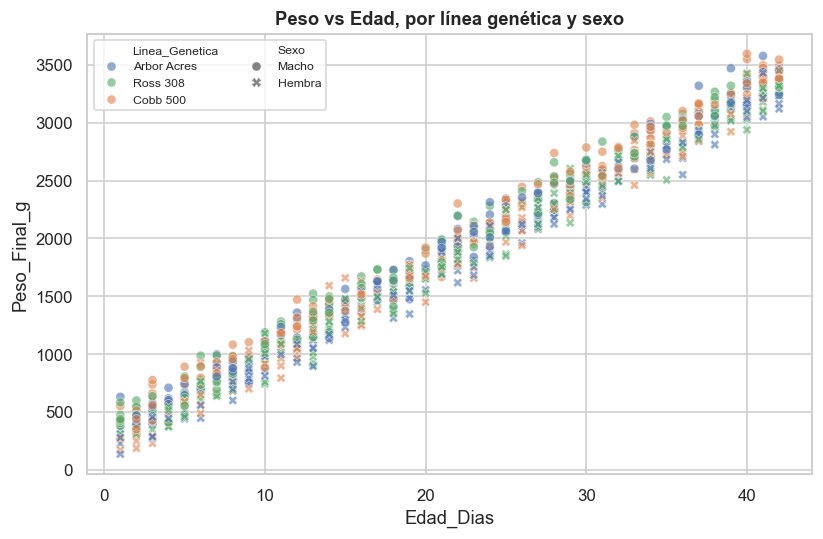

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
sns.scatterplot(data=data, x='Edad_Dias', y='Peso_Final_g', hue='Linea_Genetica',
                style='Sexo', palette=PALETTE, alpha=.6, ax=ax)
ax.set_title("Peso vs Edad, por línea genética y sexo")
ax.legend(fontsize=8, ncol=2)
plt.savefig(FIG/"04_scatter_edad_peso.png"); plt.show()

### 3.4 Información mutua (relaciones no lineales)

La correlación de Pearson solo ve relaciones lineales. La **información mutua** captura cualquier dependencia.
El veredicto es contundente: `Temperatura_C`, `Humedad_pct` y `Mortalidad_pct` tienen MI ≈ 0 (ni lineal ni
no lineal). En este dataset son, efectivamente, ruido.

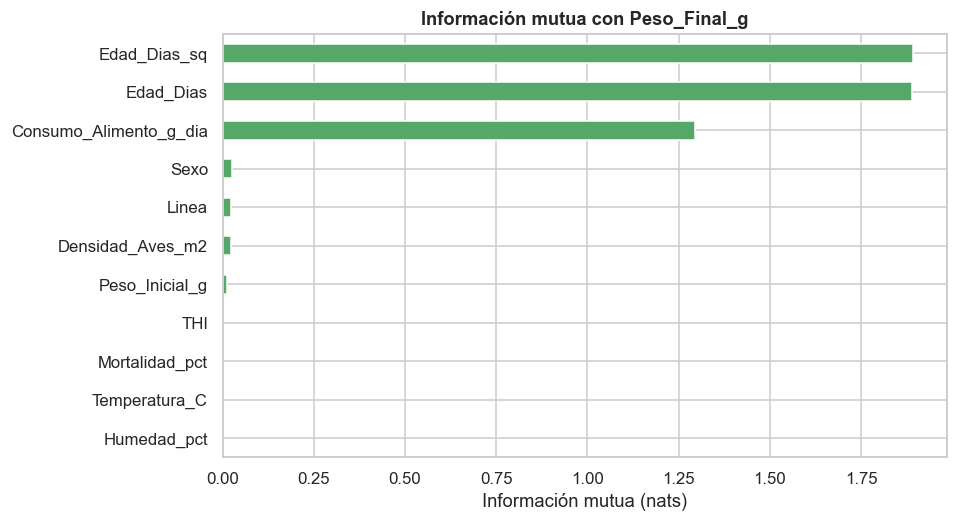

Edad_Dias_sq              1.8914
Edad_Dias                 1.8898
Consumo_Alimento_g_dia    1.2963
Sexo                      0.0252
Linea                     0.0241
Densidad_Aves_m2          0.0229
Peso_Inicial_g            0.0113
Mortalidad_pct            0.0000
Temperatura_C             0.0000
Humedad_pct               0.0000
THI                       0.0000
dtype: float64

In [14]:
from sklearn.feature_selection import mutual_info_regression
Xmi = data[SAFE_NUM].copy()
Xmi['Sexo'] = data['Sexo_macho']
Xmi['Linea'] = data['Linea_Genetica'].astype('category').cat.codes
disc = [Xmi.columns.get_loc('Sexo'), Xmi.columns.get_loc('Linea')]
mi = mutual_info_regression(Xmi, data['Peso_Final_g'], discrete_features=disc, random_state=RANDOM_STATE)
mis = pd.Series(mi, index=Xmi.columns).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 5))
mis.plot.barh(ax=ax, color="#55A868")
ax.set_xlabel("Información mutua (nats)"); ax.set_title("Información mutua con Peso_Final_g")
plt.savefig(FIG/"05_mutual_info.png"); plt.show()
mis.sort_values(ascending=False).round(4)

### 3.5 PCA — estructura de varianza del dataset

Aplicamos PCA sobre las variables numéricas estandarizadas para entender la **capacidad informativa** del
conjunto. Esperamos que la fuerte colinealidad edad–consumo colapse en un único "eje de crecimiento"
(PC1), y que las ambientales formen componentes de baja varianza casi independientes.

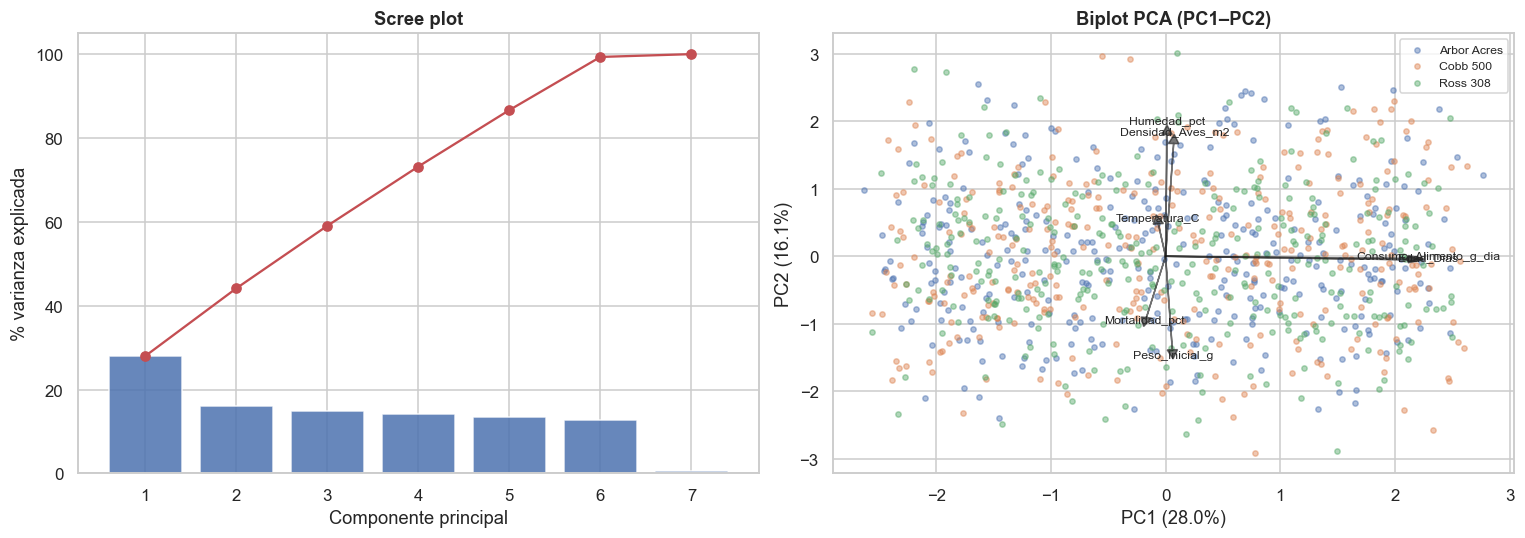

Varianza explicada por componente (%): [28.  16.1 14.9 14.1 13.5 12.7  0.7]
Acumulada (%): [ 28.   44.1  59.   73.2  86.7  99.3 100. ]


,PC1,PC2,PC3
Edad_Dias,0.705,-0.017,0.004
Consumo_Alimento_g_dia,0.706,-0.011,0.006
Temperatura_C,-0.021,0.160,0.781
Humedad_pct,0.004,0.601,-0.205
Densidad_Aves_m2,0.024,0.556,0.407
Mortalidad_pct,-0.056,-0.302,0.135
Peso_Inicial_g,0.020,-0.461,0.405


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_feats = ['Edad_Dias','Consumo_Alimento_g_dia','Temperatura_C','Humedad_pct',
             'Densidad_Aves_m2','Mortalidad_pct','Peso_Inicial_g']
Z = StandardScaler().fit_transform(data[pca_feats])
pca = PCA().fit(Z); scores = pca.transform(Z); evr = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(evr)+1), evr*100, color="#4C72B0", alpha=.85)
axes[0].plot(range(1, len(evr)+1), np.cumsum(evr)*100, '-o', color="#C44E52")
axes[0].set_xlabel("Componente principal"); axes[0].set_ylabel("% varianza explicada")
axes[0].set_title("Scree plot")
for ln, c in PALETTE.items():
    m = (data['Linea_Genetica'] == ln).values
    axes[1].scatter(scores[m, 0], scores[m, 1], s=12, alpha=.45, color=c, label=ln)
load = pca.components_
for i, f in enumerate(pca_feats):
    axes[1].arrow(0, 0, load[0, i]*3, load[1, i]*3, color="k", alpha=.6, head_width=.09)
    axes[1].text(load[0, i]*3.25, load[1, i]*3.25, f, fontsize=8, ha='center')
axes[1].set_xlabel(f"PC1 ({evr[0]*100:.1f}%)"); axes[1].set_ylabel(f"PC2 ({evr[1]*100:.1f}%)")
axes[1].set_title("Biplot PCA (PC1–PC2)"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"06_pca.png"); plt.show()

loadings = pd.DataFrame(pca.components_[:3].T, index=pca_feats, columns=["PC1","PC2","PC3"]).round(3)
print("Varianza explicada por componente (%):", (evr*100).round(1))
print("Acumulada (%):", (np.cumsum(evr)*100).round(1))
loadings

**Lectura del PCA.** PC1 está cargado por `Edad_Dias` y `Consumo_Alimento_g_dia` (el eje de crecimiento)
y es el que separa el peso. Los componentes siguientes recogen variación de las ambientales pero **no se
alinean con el objetivo** — coherente con su MI ≈ 0. Conclusión: la **dimensionalidad efectiva** del problema
es baja; un puñado de variables concentra toda la señal.

### 3.6 Capacidad predictiva incremental

Pregunta de negocio: *¿cuánto aporta cada bloque de variables?* Añadimos grupos de forma acumulada y medimos
el R² (validación cruzada, regresión lineal). Es la forma más honesta de mostrar el "techo" que otorga cada
variable.

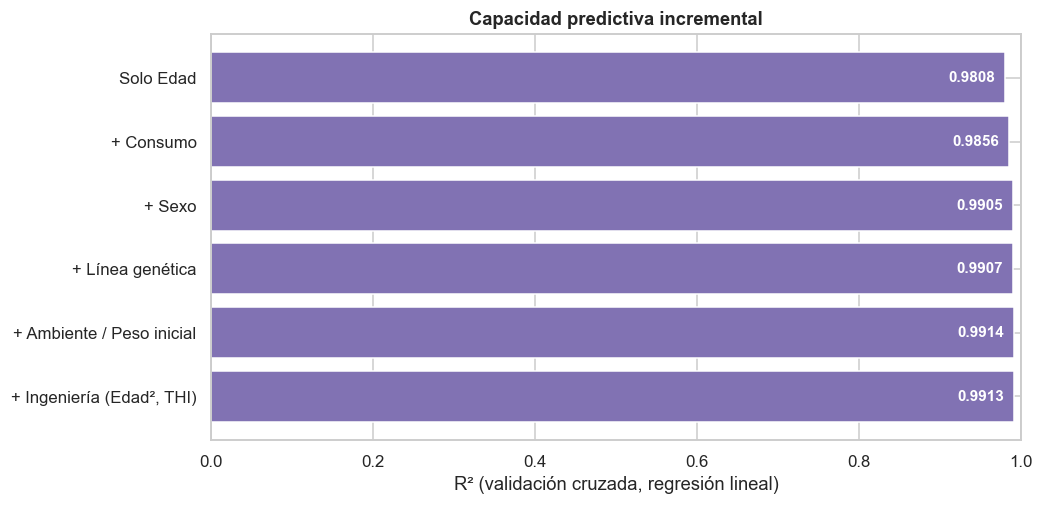

,Conjunto de variables,R2_CV
0,Solo Edad,0.9808
1,+ Consumo,0.9856
2,+ Sexo,0.9905
3,+ Línea genética,0.9907
4,+ Ambiente / Peso inicial,0.9914
5,"+ Ingeniería (Edad², THI)",0.9913


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold

y = data['Peso_Final_g'].values
cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)
groups = [
 ("Solo Edad",                 (['Edad_Dias'], [])),
 ("+ Consumo",                 (['Edad_Dias','Consumo_Alimento_g_dia'], [])),
 ("+ Sexo",                    (['Edad_Dias','Consumo_Alimento_g_dia'], ['Sexo'])),
 ("+ Línea genética",          (['Edad_Dias','Consumo_Alimento_g_dia'], ['Sexo','Linea_Genetica'])),
 ("+ Ambiente / Peso inicial", (['Edad_Dias','Consumo_Alimento_g_dia','Temperatura_C','Humedad_pct',
                                 'Densidad_Aves_m2','Mortalidad_pct','Peso_Inicial_g'], ['Sexo','Linea_Genetica'])),
 ("+ Ingeniería (Edad², THI)", (SAFE_NUM, ['Sexo','Linea_Genetica'])),
]
rows = []
for name, (nums, cats) in groups:
    steps = [("n", StandardScaler(), nums)]
    if cats: steps.append(("c", OneHotEncoder(drop='first'), cats))
    pipe = Pipeline([("prep", ColumnTransformer(steps)), ("lr", LinearRegression())])
    r2 = cross_val_score(pipe, data, y, cv=cv, scoring="r2").mean()
    rows.append((name, r2))
cap = pd.DataFrame(rows, columns=["Conjunto de variables", "R2_CV"])

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.barh(cap["Conjunto de variables"], cap["R2_CV"], color="#8172B3")
for i, v in enumerate(cap["R2_CV"]):
    ax.text(v - 0.07, i, f"{v:.4f}", va='center', color='white', fontweight='bold')
ax.set_xlim(0, 1); ax.invert_yaxis()
ax.set_xlabel("R² (validación cruzada, regresión lineal)")
ax.set_title("Capacidad predictiva incremental")
plt.savefig(FIG/"07_capacidad_incremental.png"); plt.show()
cap.round(4)

## Regla 4 — Escoge tu estrategia
### Selección de variables y preprocesamiento

**Decisión:** conservamos todas las variables seguras. Aunque ambiente y mortalidad no aporten señal *en este
dataset*, mantenerlas (a) no perjudica a modelos regularizados/árboles y (b) deja el pipeline listo para datos
futuros con más variación. Frente a la **multicolinealidad edad–consumo**, no eliminamos variables a mano:
usamos modelos que la toleran (Ridge/ElasticNet la regularizan; los árboles son inmunes).

**Preprocesamiento (en `Pipeline` para evitar fuga entre folds):**
- Numéricas → imputación por mediana + `StandardScaler`.
- Categóricas → imputación por moda + `OneHotEncoder(drop='first')`.

Partimos 80/20 **estratificando por quintiles de edad** para que train y test cubran todo el ciclo productivo.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

NUM, CAT = SAFE_NUM, SAFE_CAT
X = data[NUM + CAT].copy()
y = data['Peso_Final_g'].values

age_bins = pd.qcut(data['Edad_Dias'], 5, labels=False, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=age_bins)

num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])
cat_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                     ("oh", OneHotEncoder(drop='first', handle_unknown='ignore'))])
prep = ColumnTransformer([("num", num_pipe, NUM), ("cat", cat_pipe, CAT)])
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (800, 11) | Test: (200, 11)


## Reglas 5 y 6 — Encuentra al campeón y demuestra por qué ganó
### 5.1 Banco de modelos

Comparamos un espectro amplio: desde un **baseline** (predecir la media) hasta modelos lineales (con y sin
regularización), basados en vecindad/kernel y *ensembles* de árboles con *boosting*. La métrica de selección
es el **RMSE** (penaliza errores grandes y está en gramos, interpretable), acompañada de MAE, R² y MAPE.

In [18]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def make(model): return Pipeline([("prep", prep), ("model", model)])

modelos = {
 "Baseline (media)":  DummyRegressor(strategy="mean"),
 "Regresión Lineal":  LinearRegression(),
 "Ridge":             Ridge(alpha=1.0, random_state=RANDOM_STATE),
 "Lasso":             Lasso(alpha=0.01, random_state=RANDOM_STATE, max_iter=20000),
 "ElasticNet":        ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=20000),
 "KNN (k=10)":        KNeighborsRegressor(n_neighbors=10),
 "SVR (RBF)":         SVR(C=200, gamma='scale'),
 "Random Forest":     RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1),
 "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
 "XGBoost":           XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=4, subsample=0.9,
                                   colsample_bytree=0.9, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
 "LightGBM":          LGBMRegressor(n_estimators=400, learning_rate=0.05, max_depth=4,
                                    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
}

cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)
res = []
for name, mdl in modelos.items():
    sc = cross_validate(make(mdl), X_train, y_train, cv=cv,
                        scoring=["neg_root_mean_squared_error","neg_mean_absolute_error","r2"], n_jobs=-1)
    res.append({"Modelo": name,
                "RMSE_CV": -sc["test_neg_root_mean_squared_error"].mean(),
                "RMSE_sd":  sc["test_neg_root_mean_squared_error"].std(),
                "MAE_CV":  -sc["test_neg_mean_absolute_error"].mean(),
                "R2_CV":    sc["test_r2"].mean()})
tabla = pd.DataFrame(res).sort_values("RMSE_CV").reset_index(drop=True)
tabla.round(3)

,Modelo,RMSE_CV,RMSE_sd,MAE_CV,R2_CV
0,Lasso,85.161,3.036,68.089,0.991
1,Regresión Lineal,85.190,3.036,68.111,0.991
2,Ridge,85.340,3.125,68.283,0.991
3,ElasticNet,86.521,3.202,69.472,0.991
4,Gradient Boosting,89.703,2.490,71.162,0.990
5,XGBoost,93.075,3.090,74.278,0.989
6,LightGBM,93.116,3.739,74.592,0.989
7,Random Forest,104.042,4.991,81.977,0.987
8,SVR (RBF),145.133,7.135,109.953,0.974
9,KNN (k=10),193.715,6.879,155.138,0.954


### 5.2 Comparación visual

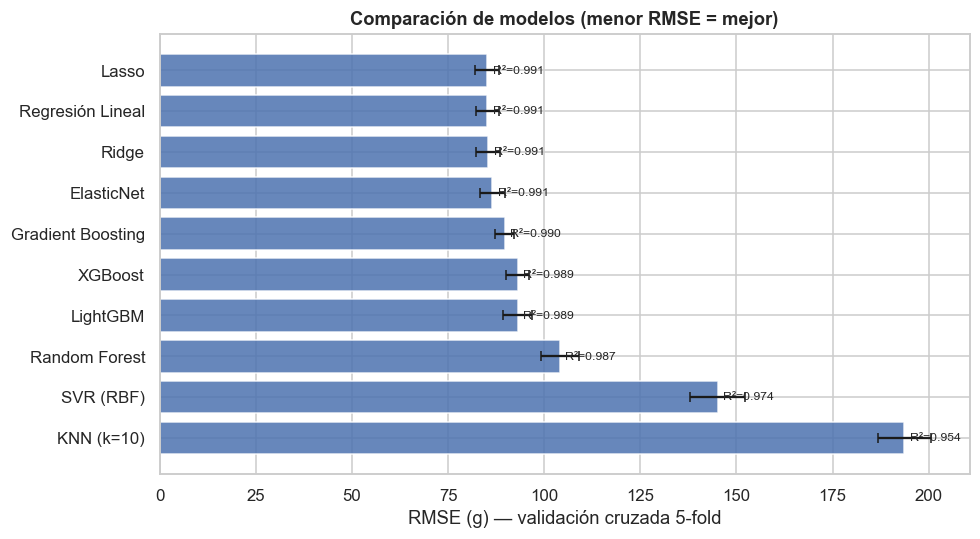

In [19]:
t = tabla[tabla["Modelo"] != "Baseline (media)"].sort_values("RMSE_CV")
fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.barh(t["Modelo"], t["RMSE_CV"], xerr=t["RMSE_sd"], color="#4C72B0", alpha=.85, capsize=3)
for i, (v, r2) in enumerate(zip(t["RMSE_CV"], t["R2_CV"])):
    ax.text(v + 1.5, i, f"R²={r2:.3f}", va='center', fontsize=8)
ax.set_xlabel("RMSE (g) — validación cruzada 5-fold"); ax.invert_yaxis()
ax.set_title("Comparación de modelos (menor RMSE = mejor)")
plt.savefig(FIG/"08_comparacion_modelos.png"); plt.show()

### 6.1 Selección del campeón y evaluación en test

Elegimos por menor RMSE de validación cruzada, pero aplicamos el **principio de parsimonia**: si la regresión
lineal queda a un margen ínfimo del mejor modelo, se prefiere por interpretabilidad, velocidad y facilidad de
despliegue. Evaluamos en el conjunto de test **no visto**.

In [20]:
def met(yt, yp):
    rmse = mean_squared_error(yt, yp) ** 0.5
    return rmse, mean_absolute_error(yt, yp), r2_score(yt, yp), np.mean(np.abs((yt-yp)/yt))*100

best_name = tabla.iloc[0]["Modelo"]
rmse_lin  = tabla.loc[tabla["Modelo"]=="Regresión Lineal","RMSE_CV"].values[0]
rmse_best = tabla.iloc[0]["RMSE_CV"]
print(f"Mejor por RMSE_CV: {best_name}")
print(f"RMSE Regresión Lineal = {rmse_lin:.2f} g | Mejor = {rmse_best:.2f} g | diferencia = {rmse_lin-rmse_best:.2f} g\n")

campeon = make(modelos[best_name]).fit(X_train, y_train)
pred = campeon.predict(X_test)
print(f"TEST · {best_name:18s}: RMSE={met(y_test,pred)[0]:.1f} g | MAE={met(y_test,pred)[1]:.1f} g | "
      f"R²={met(y_test,pred)[2]:.4f} | MAPE={met(y_test,pred)[3]:.2f}%")

lin = make(LinearRegression()).fit(X_train, y_train)
plr = lin.predict(X_test)
print(f"TEST · {'Regresión Lineal':18s}: RMSE={met(y_test,plr)[0]:.1f} g | MAE={met(y_test,plr)[1]:.1f} g | "
      f"R²={met(y_test,plr)[2]:.4f} | MAPE={met(y_test,plr)[3]:.2f}%")
rmse, mae, r2, mape = met(y_test, pred)

Mejor por RMSE_CV: Lasso
RMSE Regresión Lineal = 85.19 g | Mejor = 85.16 g | diferencia = 0.03 g

TEST · Lasso             : RMSE=83.1 g | MAE=64.6 g | R²=0.9921 | MAPE=5.82%
TEST · Regresión Lineal  : RMSE=83.1 g | MAE=64.6 g | R²=0.9921 | MAPE=5.82%


### 6.2 Diagnóstico del campeón

Dos gráficos de validación de modelo de regresión: **predicho vs real** (debe pegarse a la diagonal) y
**residuos vs predicho** (deben distribuirse alrededor de 0 sin patrón = homocedasticidad y ausencia de sesgo).

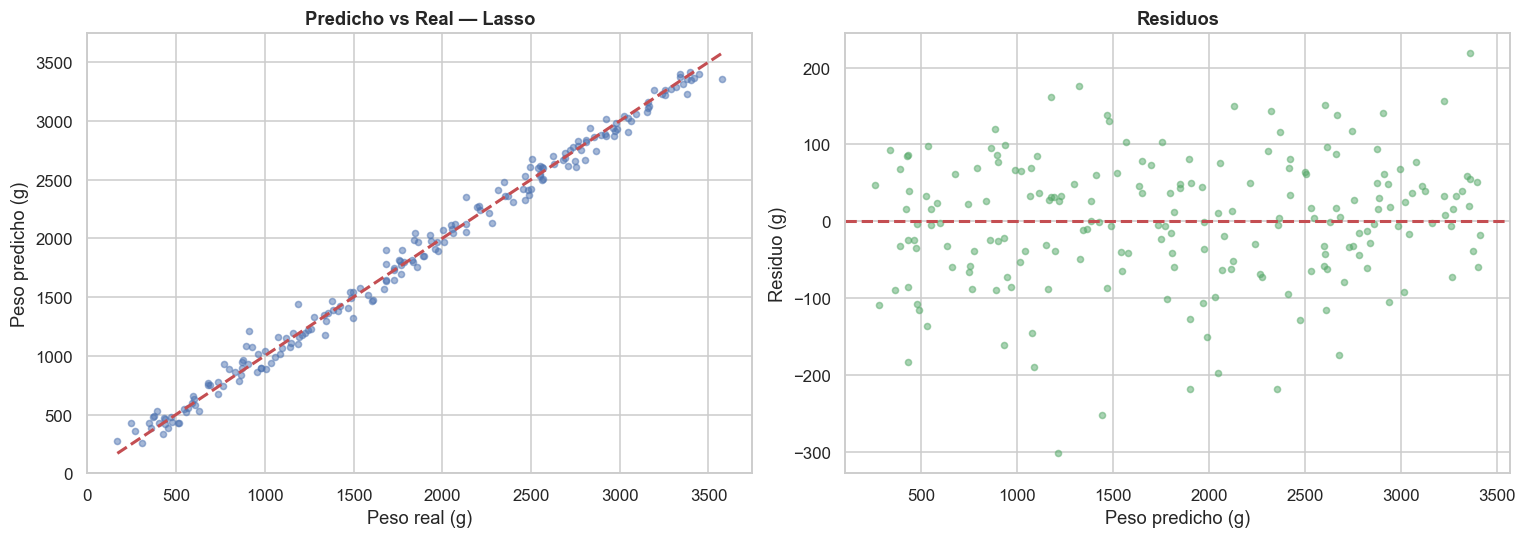

Residuos en test -> media=-0.52 g | sd=83.08 g


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, pred, s=16, alpha=.5, color="#4C72B0")
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
axes[0].plot(lims, lims, '--', color="#C44E52", lw=2)
axes[0].set_xlabel("Peso real (g)"); axes[0].set_ylabel("Peso predicho (g)")
axes[0].set_title(f"Predicho vs Real — {best_name}")
resid = y_test - pred
axes[1].scatter(pred, resid, s=16, alpha=.5, color="#55A868")
axes[1].axhline(0, ls='--', color="#C44E52", lw=2)
axes[1].set_xlabel("Peso predicho (g)"); axes[1].set_ylabel("Residuo (g)")
axes[1].set_title("Residuos")
plt.tight_layout(); plt.savefig(FIG/"09_diagnostico_campeon.png"); plt.show()
print(f"Residuos en test -> media={resid.mean():.2f} g | sd={resid.std():.2f} g")

## Regla 7 — Convierte datos en decisiones
### 7.1 Variables más importantes (importancia por permutación)

La importancia por permutación mide cuánto **empeora el RMSE** al barajar cada variable: es agnóstica al
modelo y honesta. Confirma que la edad y el consumo son los pilares de la predicción.

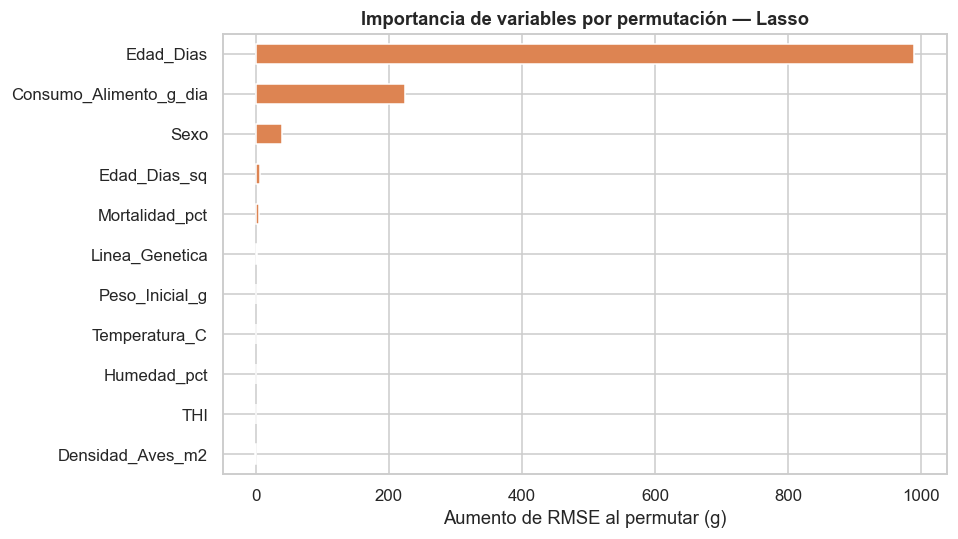

Edad_Dias                 989.22
Consumo_Alimento_g_dia    223.70
Sexo                       39.44
Edad_Dias_sq                6.83
Mortalidad_pct              4.47
Linea_Genetica              2.37
Peso_Inicial_g              0.94
Temperatura_C               0.22
Humedad_pct                -0.02
THI                        -0.09
Densidad_Aves_m2           -0.25
dtype: float64

In [22]:
from sklearn.inspection import permutation_importance
pi = permutation_importance(campeon, X_test, y_test, n_repeats=20, random_state=RANDOM_STATE,
                            scoring="neg_root_mean_squared_error", n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 5.2))
imp.plot.barh(ax=ax, color="#DD8452")
ax.set_xlabel("Aumento de RMSE al permutar (g)")
ax.set_title(f"Importancia de variables por permutación — {best_name}")
plt.savefig(FIG/"10_importancia.png"); plt.show()
imp.sort_values(ascending=False).round(2)

### 7.2 ¿Qué línea genética conviene engordar? (efecto **ajustado** por edad y sexo)

Comparar las medias crudas de peso por línea es **engañoso**, porque cada línea puede tener distinta mezcla de
edades. La forma correcta y auditable es un **modelo lineal que controla edad y sexo**, dejando aislado el
efecto neto de la línea (con sus intervalos de confianza al 95%).

In [23]:
m = smf.ols("Peso_Final_g ~ Edad_Dias + C(Sexo) + C(Linea_Genetica)", data=data).fit()
print(m.summary().tables[1])
print(f"\nR² del modelo explicativo: {m.rsquared:.4f}")

ci = m.conf_int().loc[[i for i in m.params.index if 'Linea' in i or 'Sexo' in i]]
ci.columns = ['IC_95_inf', 'IC_95_sup']
efectos = pd.concat([m.params.rename('Efecto_g'), ci], axis=1).loc[ci.index].round(1)
print("\nEfectos ajustados (vs categoría base: Arbor Acres / Hembra):")
efectos

                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                       174.1945      8.811     19.769      0.000     156.903     191.486
C(Sexo)[T.Macho]                126.4405      6.740     18.759      0.000     113.214     139.667
C(Linea_Genetica)[T.Cobb 500]    44.2748      8.246      5.369      0.000      28.093      60.456
C(Linea_Genetica)[T.Ross 308]    25.2319      8.215      3.071      0.002       9.110      41.353
Edad_Dias                        74.0841      0.277    267.815      0.000      73.541      74.627

R² del modelo explicativo: 0.9864

Efectos ajustados (vs categoría base: Arbor Acres / Hembra):


,Efecto_g,IC_95_inf,IC_95_sup
C(Sexo)[T.Macho],126.4,113.2,139.7
C(Linea_Genetica)[T.Cobb 500],44.3,28.1,60.5
C(Linea_Genetica)[T.Ross 308],25.2,9.1,41.4


### 7.3 Monetización: traducir gramos a dólares

Convertimos las diferencias de peso en **dinero** usando precios de referencia **auditables** del mercado
ecuatoriano (ver fuentes en el informe):

- **Pollo en pie:** ~US$0.65–0.85/lb ⇒ **≈ US$1.45–1.85/kg**. Caso base **US$1.65/kg**.
- **Balanceado de engorde:** maíz amarillo a US$0.428/kg (insumo principal) + manufactura ⇒ caso base
  **US$0.72/kg**.

Calculamos el ingreso por ave a faena (≥35 días) por línea y el **impacto por lote de 10 000 aves**.

In [24]:
PRECIO_PIE_USD_KG = 1.65          # caso base (~US$0.75/lb)
PRECIO_PIE_RANGO  = (1.45, 1.85)  # sensibilidad
LOTE = 10_000

FAENA = data[data['Edad_Dias'] >= 35].copy()
tab_linea = FAENA.groupby('Linea_Genetica').agg(
    peso_g=('Peso_Final_g', 'mean'),
    consumo_dia_g=('Consumo_Alimento_g_dia', 'mean'),
    n=('Peso_Final_g', 'size')).sort_values('peso_g', ascending=False)
tab_linea['peso_kg'] = tab_linea['peso_g'] / 1000
tab_linea['ingreso_ave_usd'] = tab_linea['peso_kg'] * PRECIO_PIE_USD_KG

ref = 'Arbor Acres'
tab_linea['delta_kg_vs_base'] = tab_linea['peso_kg'] - tab_linea.loc[ref, 'peso_kg']
tab_linea['delta_USD_lote'] = tab_linea['delta_kg_vs_base'] * PRECIO_PIE_USD_KG * LOTE
print("Peso e ingreso por línea a faena (>=35 días), referencia = Arbor Acres:\n")
print(tab_linea.round(2).to_string())

print("\n--- Efectos AJUSTADOS (control edad+sexo) monetizados, por lote de 10.000 aves ---")
for ln in ['Cobb 500', 'Ross 308']:
    eff = m.params[f'C(Linea_Genetica)[T.{ln}]']
    lo, hi = eff/1000*PRECIO_PIE_RANGO[0]*LOTE, eff/1000*PRECIO_PIE_RANGO[1]*LOTE
    print(f"{ln:11s} vs Arbor: +{eff:5.0f} g/ave -> +US${eff/1000*PRECIO_PIE_USD_KG*LOTE:6,.0f}/lote "
          f"(rango US${lo:,.0f}–{hi:,.0f})")
sx = m.params['C(Sexo)[T.Macho]']
print(f"{'Macho':11s} vs Hembra: +{sx:5.0f} g/ave -> +US${sx/1000*PRECIO_PIE_USD_KG*LOTE:6,.0f}/lote "
      f"(el sexo pesa más que la línea)")

Peso e ingreso por línea a faena (>=35 días), referencia = Arbor Acres:

                 peso_g  consumo_dia_g   n  peso_kg  ingreso_ave_usd  delta_kg_vs_base  delta_USD_lote
Linea_Genetica                                                                                        
Cobb 500        3171.79         190.68  66     3.17             5.23              0.09         1481.18
Ross 308        3097.42         188.42  60     3.10             5.11              0.02          254.08
Arbor Acres     3082.02         184.88  62     3.08             5.09              0.00            0.00

--- Efectos AJUSTADOS (control edad+sexo) monetizados, por lote de 10.000 aves ---
Cobb 500    vs Arbor: +   44 g/ave -> +US$   731/lote (rango US$642–819)
Ross 308    vs Arbor: +   25 g/ave -> +US$   416/lote (rango US$366–467)
Macho       vs Hembra: +  126 g/ave -> +US$ 2,086/lote (el sexo pesa más que la línea)


### 7.4 Consumo y eficiencia alimentaria (FCR) por línea

El FCR (kg de alimento por kg ganado) es **el** indicador de eficiencia en avicultura. Aquí solo disponemos
del **consumo diario puntual**, no del acumulado, por lo que el FCR es un **proxy referencial** (lo señalamos
explícitamente). Aun así, ordena a las líneas y se contrasta con la literatura.

In [25]:
desc_f = desc.loc[FAENA.index]
fcr = (FAENA.assign(FCR=desc_f['FCR_aprox'], consumo_dia=FAENA['Consumo_Alimento_g_dia'])
            .groupby('Linea_Genetica')[['FCR', 'consumo_dia']].mean()
            .rename(columns={'FCR': 'FCR_proxy', 'consumo_dia': 'consumo_dia_g'}))
fcr['ranking_peso'] = tab_linea['peso_g'].rank(ascending=False).astype(int)
print("Eficiencia por línea a faena (>=35 días) — FCR es proxy referencial:\n")
print(fcr.round(3).to_string())

Eficiencia por línea a faena (>=35 días) — FCR es proxy referencial:

                FCR_proxy  consumo_dia_g  ranking_peso
Linea_Genetica                                        
Arbor Acres         2.345        184.879             3
Cobb 500            2.373        190.680             1
Ross 308            2.375        188.423             2


### 7.5 Hallazgos y recomendaciones (capitalizables)

1. **Predicción operativa.** Con `Edad_Dias` + `Consumo_Alimento_g_dia` (+ sexo y línea) se predice el peso
   con error porcentual de ~pocos %. Un modelo lineal basta y es desplegable hoy: permite **proyectar el peso
   de faena** de cada lote y planificar logística y ventas.
2. **Elección de estirpe.** **Cobb 500** maximiza el peso a faena (efecto ajustado positivo y significativo),
   seguida de **Ross 308**; **Arbor Acres** es la base. Recomendación: priorizar **Cobb 500** para producción
   orientada a kilos, salvo que el precio del pollito BB o el FCR real inviertan el margen.
3. **Sexo > línea.** El dimorfismo sexual (+~126 g en machos) supera al efecto de línea. Para maximizar kilos,
   evaluar **crianza sexada** o lotes con mayor proporción de machos (considerando costo de sexado y demanda).
4. **Calidad de dato como prioridad.** Temperatura, humedad, densidad y mortalidad **no muestran señal**. La
   literatura indica que sí deberían influir; lo más probable es que estén mal capturadas o sean sintéticas.
   **Recomendación de inversión:** mejorar sensórica y trazabilidad ambiental para futuros modelos.
5. **Ventana de faena.** El crecimiento es sostenido hasta el día 42; la decisión de faena es económica
   (precio/kg vs costo marginal de alimento), no de meseta de peso en este rango.

## 8. Persistencia de resultados

Guardamos tablas y un resumen ejecutivo en `../outputs/` para alimentar el informe y la presentación.

In [26]:
tabla.to_csv(TAB/"comparacion_modelos.csv", index=False)
cap.to_csv(TAB/"capacidad_incremental.csv", index=False)
tab_linea.round(3).to_csv(TAB/"analisis_lineas.csv")
efectos.to_csv(TAB/"efectos_ajustados.csv")
resumen.to_csv(TAB/"calidad_datos.csv")

summary = {
 "n_registros": int(df.shape[0]),
 "n_variables": int(df.shape[1]),
 "mejor_modelo": best_name,
 "rmse_test_g": round(float(rmse), 2),
 "mae_test_g": round(float(mae), 2),
 "r2_test": round(float(r2), 4),
 "mape_test_pct": round(float(mape), 2),
 "rmse_regresion_lineal_cv_g": round(float(rmse_lin), 2),
 "efecto_cobb_vs_arbor_g": round(float(m.params['C(Linea_Genetica)[T.Cobb 500]']), 1),
 "efecto_ross_vs_arbor_g": round(float(m.params['C(Linea_Genetica)[T.Ross 308]']), 1),
 "efecto_macho_vs_hembra_g": round(float(m.params['C(Sexo)[T.Macho]']), 1),
 "peso_faena_top_linea": tab_linea.index[0],
 "r2_explicativo": round(float(m.rsquared), 4),
}
with open(TAB/"resumen_ejecutivo.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "n_registros": 1000,
  "n_variables": 11,
  "mejor_modelo": "Lasso",
  "rmse_test_g": 83.08,
  "mae_test_g": 64.58,
  "r2_test": 0.9921,
  "mape_test_pct": 5.82,
  "rmse_regresion_lineal_cv_g": 85.19,
  "efecto_cobb_vs_arbor_g": 44.3,
  "efecto_ross_vs_arbor_g": 25.2,
  "efecto_macho_vs_hembra_g": 126.4,
  "peso_faena_top_linea": "Cobb 500",
  "r2_explicativo": 0.9864
}


## 9. Limitaciones y próximos pasos

- **Dato sintético / lineal:** la relación peso–edad es lineal con intercepto no físico; un dataset real
  (curva de Gompertz) exigiría términos no lineales que aquí ya dejamos habilitados (`Edad_Dias_sq`).
- **FCR aproximado:** sin consumo **acumulado** no se computa el FCR verdadero; se recomienda registrar
  consumo por fase (iniciador/crecimiento/engorde).
- **Sin variable de precio en el dato:** la monetización usa referencias externas auditables; integrar
  precios de mercado por fecha permitiría un módulo de **margen por lote** automático.
- **Validación temporal:** con marca de tiempo de lote, migrar a validación *out-of-time* para simular
  despliegue real.

---
*Cuaderno reproducible — semilla `42`. Referencias bibliográficas y de precios en el informe (`informe/`).*